Your current structure is perfectly fine.

Just go inside the project folder:

cd recommendation_system

Then create the venv:

Windows

python -m venv venv

Activate:

venv\Scripts\activate


---

After activation install packages:

pip install pandas numpy scikit-learn matplotlib seaborn jupyter surprise fastapi uvicorn


---

🧠 Important Understanding

The virtual environment is just an isolated Python environment stored inside a folder (venv/).

It does NOT need to exist before creating:

data/

src/

models/

etc.


So your order is completely okay.


---

📌 One More Important Thing

After installing packages:

pip freeze > requirements.txt

This stores exact package versions.

Very important in real projects.


---

Your folder will finally look like:

recommendation_system/
│
├── venv/
├── data/
├── notebooks/
├── src/
├── models/
├── api/
├── logs/
└── requirements.txt

Perfect industry-style setup.


# 🚀 Day 1 — Intelligent Recommendation System Project

Welcome to the start of your next killer project.

This one is important because it teaches:

real-world ML pipelines

recommendation algorithms

backend APIs

deployment thinking

personalization systems


This project will look much closer to actual industry ML systems than tutorial projects.


---

🎯 Final Goal

Build a mini version of:

Netflix

Amazon

YouTube


using:

collaborative filtering

content-based recommendation

hybrid recommendation

FastAPI backend

monitoring/logging

evaluation metrics



---

🧠 What Happens on Day 1

Today is mainly:

1. Understanding recommendation systems deeply


2. Setting up environment


3. Loading dataset


4. Performing exploration


5. Understanding users/items/ratings structure



NO heavy ML today.

Today builds the foundation.


---

🧩 First Understand Recommendation Systems

There are mainly 3 types:


---

1️⃣ Content-Based Recommendation

Recommend items similar to what user already likes.

Example:

User watched:

Batman

Superman



System recommends:

Spider-Man


because genres/features are similar.

Works using:

similarity

embeddings

cosine similarity

TF-IDF



---

2️⃣ Collaborative Filtering

“Users similar to you liked this.”

Example:

User A likes:

Interstellar

Inception


User B likes:

Interstellar

Inception

Tenet



System recommends:

Tenet to User A


This is the MOST IMPORTANT technique.


---

3️⃣ Hybrid Recommendation

Combination of:

content-based

collaborative filtering


Used by almost all major companies.


---

🧠 Important Industry Concepts

You’ll hear these everywhere:

Term	Meaning

User	Person using system
Item	Movie/product/video
Rating	User feedback
Explicit feedback	Ratings like 4/5
Implicit feedback	Clicks/watch time
Cold start	New user/item problem
Similarity	How close items/users are
Matrix Factorization	Core recommendation technique



---

📦 Dataset We’ll Use

We’ll use:

MovieLens 100K

Why?

industry-famous dataset

beginner friendly

perfect size

widely used in research


Contains:

users

movies

ratings



---

🛠️ Day 1 Setup

Step 1 — Create Project Folder

mkdir recommendation_system
cd recommendation_system


---

Step 2 — Create Virtual Environment

Windows

python -m venv venv
venv\Scripts\activate

Mac/Linux

python3 -m venv venv
source venv/bin/activate


---

Step 3 — Install Libraries

pip install pandas numpy scikit-learn matplotlib seaborn jupyter surprise fastapi uvicorn

Important:

surprise → recommendation algorithms

fastapi → backend later

uvicorn → API server



---

📁 Recommended Project Structure

recommendation_system/
│
├── data/
├── notebooks/
├── src/
├── models/
├── api/
├── logs/
└── requirements.txt

Create them now.


---

📥 Step 4 — Download Dataset

Download:

MovieLens Dataset

Download:

ml-100k.zip


Extract into:

data/


---

📘 Step 5 — Create First Notebook

Create:

notebooks/day1_eda.ipynb


---

🧪 Day 1 Coding Tasks


---

Task 1 — Load Dataset

import pandas as pd

ratings_cols = ['user_id', 'movie_id', 'rating', 'timestamp']

ratings = pd.read_csv(
    '../data/ml-100k/u.data',
    sep='\t',
    names=ratings_cols
)

ratings.head()


---

Task 2 — Load Movie Names

movie_cols = ['movie_id', 'title']

movies = pd.read_csv(
    '../data/ml-100k/u.item',
    sep='|',
    encoding='latin-1',
    usecols=[0, 1],
    names=movie_cols
)

movies.head()


---

Task 3 — Merge Datasets

df = pd.merge(ratings, movies, on='movie_id')

df.head()


---

🔍 Task 4 — Explore Dataset

Try these:

Shape

df.shape

Unique users

df['user_id'].nunique()

Unique movies

df['movie_id'].nunique()

Rating distribution

df['rating'].value_counts()


---

📊 Task 5 — Plot Ratings Distribution

import matplotlib.pyplot as plt

df['rating'].hist()
plt.show()


---

🧠 VERY IMPORTANT OBSERVATION

Recommendation systems are NOT normal ML.

Why?

Because:

there are no traditional features initially

data is sparse

users rate only few items

system learns relationships


This changes how ML is approached.


---

🎯 Your Day 1 Goals

By end of today you should understand:

what recommendation systems are

collaborative vs content-based

structure of recommendation datasets

how users/items/ratings connect

basic dataset exploration



---

📌 Homework (Important)

After EDA, answer these questions yourself:

1. Which rating occurs most?


2. Are users rating many movies or few?


3. Is the dataset sparse?


4. Why is sparsity difficult?


5. Why recommendation systems are different from classification?



These questions build intuition.


---

🚀 Tomorrow (Day 2)

We’ll build:

Popularity-Based Recommendation System

You’ll create:

top-rated movies recommender

weighted ranking system

minimum rating filters


This becomes your FIRST working recommender engine.



In [1]:
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# IMPORTS
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

import pandas as pd

import matplotlib.pyplot as plt

In [2]:
# Load dataset

ratings_cols = [ 'user_id', 'movie_id', 'rating', 'timestamp' ]

ratings = pd.read_csv ( r"C:\Users\Mugundhan\ML_Learning\recommendation_system\data\ml-100k\u.data", sep = '\t', names = ratings_cols )

ratings.head()

,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [3]:
# Load Movie names

movie_cols = [ 'movie_id', 'title' ]

movies = pd.read_csv ( r"C:\Users\Mugundhan\ML_Learning\recommendation_system\data\ml-100k\u.item", sep = '|', encoding = 'latin-1', usecols = [0, 1], names = movie_cols )

movies.head()

,movie_id,title
0,1,Toy Story (1995)
1,2,GoldenEye (1995)
2,3,Four Rooms (1995)
3,4,Get Shorty (1995)
4,5,Copycat (1995)


In [4]:
# Merge datasets

df = pd.merge ( ratings, movies, on = 'movie_id' )

df.head()

,user_id,movie_id,rating,timestamp,title
0,196,242,3,881250949,Kolya (1996)
1,186,302,3,891717742,L.A. Confidential (1997)
2,22,377,1,878887116,Heavyweights (1994)
3,244,51,2,880606923,Legends of the Fall (1994)
4,166,346,1,886397596,Jackie Brown (1997)


In [5]:
# explore dataset

df.shape

(100000, 5)

In [6]:
df [ 'user_id' ].nunique()

943

In [7]:
df [ 'movie_id' ].nunique()

1682

In [8]:
df [ 'rating' ].value_counts()

rating
4    34174
3    27145
5    21201
2    11370
1     6110
Name: count, dtype: int64

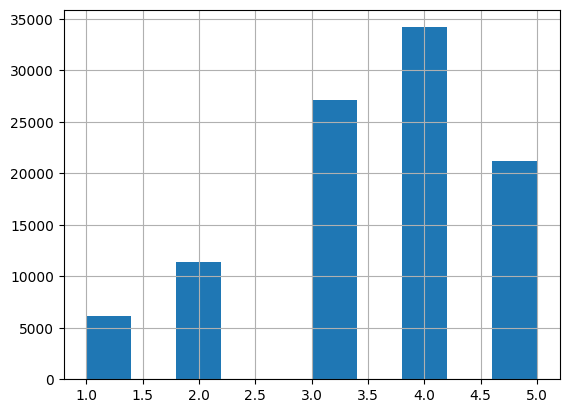

In [9]:
df [ 'rating' ].hist()
plt.show()

Good. You’re already thinking in the correct direction instead of memorizing definitions.
That’s exactly how recommendation systems should be learned.

Let’s refine each answer deeper.


---

✅ 1️⃣ Which rating occurs most?

You answered:

> Rating 4 occurs most



Correct.

This usually means:

users are generally positive

people tend to rate movies they like

ratings are biased toward good experiences


This is common in recommendation systems.


---

✅ 2️⃣ Are users rating many movies or few?

You said:

> Not every user is rating because users = 943 and movies = 1682



Correct intuition.

But the deeper observation is:

Total possible ratings:

943 \times 1682 = 1,586,126

Actual ratings in dataset:

only 100,000


That means MOST user-movie combinations are missing.

Huge missing space.


---

✅ 3️⃣ Is dataset sparse?

YES. Extremely sparse.

Now you can mathematically see why.

Sparsity means:

Most users have NOT interacted with most movies.

Formula:

\text{Sparsity} = 1 - \frac{\text{Observed Ratings}}{\text{Possible Ratings}}

For this dataset:

1 - \frac{100000}{1586126} \approx 0.937

≈ 94% sparse.

That is HUGE.


---

✅ 4️⃣ Why is sparsity difficult?

This is VERY important.

Because ML learns patterns from data.

But here:

most entries are missing

most users watched very few movies

many movies have very few ratings


So system struggles to:

find similar users

find similar items

generalize preferences


Example:

User A watched:
Batman, Superman

User B watched:
Titanic only

No overlap.

Then similarity becomes hard.

Sparse data is one of the BIGGEST problems in recommendation systems.


---

✅ 5️⃣ Why recommendation systems differ from classification?

Your answer is GOOD. Especially this:

> users may/may not give review



Excellent observation.

Now let’s refine it professionally.


---

Classification

Traditional ML:

Features → Target

Example:

transaction amount

IP

location


→ fraud/not fraud

Every row usually has:

full features

fixed target



---

Recommendation Systems

Here:

there are no normal features initially

interactions are incomplete

preferences are subjective

missing data dominates


Instead of predicting:

class label

we predict:

user preference

That’s fundamentally different.


---

⚠️ One Important Correction

You said:

> multiple dependent variable



Not exactly.

Usually:

target is still ONE thing:

rating

preference score

probability of liking



But the challenge is:

target matrix is mostly empty

relationships matter more than features



---

🧠 MOST IMPORTANT INSIGHT TODAY

In fraud detection:

data rows are independent


In recommendation systems:

users influence users

items influence items

relationships matter more than raw features


This is why recommendation systems become a graph/relationship problem rather than classic tabular ML.

That conceptual shift is the core of this project.



“Why THIS data?” “Why THIS structure?” “Why THIS approach?” “What changes if we do it differently?”



That’s where real understanding starts.


---

🧩 First Understand the Dataset Structure

The MovieLens 100K dataset is split into multiple files because real-world systems separate data by entity type.

Think database design.


---

📁 u.data

Contains:

user_id | movie_id | rating | timestamp

Example:

196 242 3 881250949

Meaning:

User 196

rated Movie 242

with rating 3



---

📁 u.item

Contains:

movie_id | title | release_date | genres...

Example:

1 | Toy Story (1995)

Meaning: Movie ID 1 corresponds to Toy Story.


---

❓WHY Separate Files?

This is NORMAL database normalization.

Because:

movie details repeat many times otherwise

saves storage

easier updates

scalable


Imagine 100 million ratings.

Without separation:

user_id | movie_name | genre | release_date | rating

Movie details repeat millions of times.

Wasteful.

So industry systems separate:

interactions

item metadata

user metadata



---

🎯 Why We Choose u.data

Because recommendation systems fundamentally learn from:

USER ↔ ITEM interactions

This file contains the MOST important information:

who interacted

with what

how strongly


Without this: there is NO recommendation system.

This is the CORE dataset.


---

🎯 Why We Choose u.item

Because:

IDs alone are meaningless to humans


Example:

movie_id = 1

means nothing.

After merge:

1 → Toy Story

Now recommendations become understandable.


---

❓Why Merge Them?

This is VERY important.

Initially:

ratings table	movies table

movie_id	movie_id
rating	title


These are RELATED tables.

We merge because:

ratings alone lack movie context

movies alone lack user interactions


Together they become useful.


---

🧠 Real Engineering Analogy

Think of:

Orders table

Products table


In e-commerce.

You merge them to understand:

which products sell

customer behavior

product popularity


Same idea here.


---

⚠️ What Happens If We DON'T Merge?

Then outputs become:

Recommended movie:
movie_id = 257

Not useful.

After merge:

Recommended movie:
Men in Black (1997)

Now meaningful.


---

❓Why NOT Use Other Files?

Excellent thinking.

MovieLens contains:

u.user

u.genre

u.occupation

etc.


We intentionally IGNORE them initially.

Why?

Because Day 1 goal is:

Understand interaction-based recommendation first.

Too much data initially creates confusion.


---

🧠 Why Recommendation Systems Start Simple

Because the MOST IMPORTANT signal is usually:

interaction behavior

NOT demographics.

Netflix cares more about:

what you watched


than:

your age

your job


Behavior > profile data.


---

❓Could We Use Only u.item?

NO.

Then we only know:

movie names

genres


But:

no user preferences

no ratings

no interactions


Impossible to personalize.

You’d only build:

genre filtering

static recommendations


NOT collaborative recommendation.


---

❓Could We Use Only u.data?

Technically YES.

Algorithms can train using:

user_id

movie_id

rating


because models only need IDs mathematically.

BUT:

humans cannot interpret outputs

debugging becomes difficult

visualizations become unreadable


So we merge for interpretability.


---

🧠 MOST IMPORTANT UNDERSTANDING

Recommendation systems are basically:

Relationship Learning

The system learns:

Which users connect to which items

Everything else is secondary.


---

🔥 Why This Design Matters Later

This structure enables:

collaborative filtering

matrix factorization

embeddings

nearest-neighbor systems

graph recommendations


because all depend on:

\text{User} \times \text{Item} \rightarrow \text{Interaction}

That interaction matrix is the HEART of recommendation systems.


---

🧠 Big Industry Insight

Classification datasets usually look like:

row = independent sample

Recommendation datasets look like:

row = relationship between entities

That is the conceptual shift.

